# Iman Noor
---

# **Deep Learning with TensorFlow/Keras**

## **1. Understanding Neural Networks**

Neural networks are computational models inspired by the human brain. They consist of layers of neurons that process input data to extract patterns and make predictions. The basic building block is the perceptron, which we have previously studied.

### **1.1 Perceptron**

A perceptron is a simple neural network model that consists of:
- **Input Layer**: Receives the input data.
- **Weights**: Multiply the input values.
- **Bias**: Adjusts the output along with weights.
- **Activation Function**: Introduces non-linearity to the model.

The output `y` of a perceptron is calculated as:
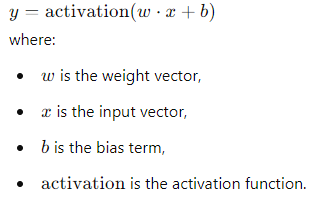

### **1.2 Activation Functions**

Activation functions introduce non-linearity into the model. Common activation functions include:
- **Sigmoid**: 

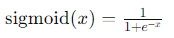

- **ReLU (Rectified Linear Unit)**: 


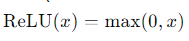

## **2. Building the Model with TensorFlow/Keras**

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

2024-08-13 10:26:04.550142: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-13 10:26:04.550204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-13 10:26:04.551748: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### **Prepare the Data**

Generating a synthetic dataset and preprocess it for training:


In [2]:
X = np.vstack([(np.random.rand(10, 2) * 5), (np.random.rand(10, 2) * 10)])
Y = np.hstack([[0]*10, [1]*10])
Y_one_hot = to_categorical(Y, num_classes=2)


### **Define the Model Architecture**

Creating a Sequential model with multiple hidden layers:


In [3]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)), # input layer
    Dropout(0.5), # for regularization
    Dense(32, activation='relu'), # hidden layer
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')
])

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Compile the Model**

Configuring the model with loss function, optimizer, and metrics:

In [4]:
model.compile(optimizer=Adam(learning_rate=0.0001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])

### **Train the Model**

Fit the model to the data:


In [5]:
history = model.fit(X, Y_one_hot, epochs=100, validation_split=0.2, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5000 - loss: 0.8891

I0000 00:00:1723544773.935955     651 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 0.8891 - val_accuracy: 1.0000 - val_loss: 0.5475
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4375 - loss: 1.1039 - val_accuracy: 1.0000 - val_loss: 0.5490
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.8003 - val_accuracy: 1.0000 - val_loss: 0.5510
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3750 - loss: 0.7209 - val_accuracy: 1.0000 - val_loss: 0.5526
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3750 - loss: 0.8149 - val_accuracy: 1.0000 - val_loss: 0.5544
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3125 - loss: 0.9001 - val_accuracy: 1.0000 - val_loss: 0.5561
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2500 - loss: 1.1151 - val_accuracy: 1.0000 - val_loss: 0.5579
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4375 - loss: 0.7704 - val_accuracy: 1.0000 - val_loss: 0.5596
Epoch 

### **Evaluate the Model**

Assessing the model's performance:

In [6]:
loss, accuracy = model.evaluate(X, Y_one_hot)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.8000 - loss: 0.6552
Loss: 0.6552489995956421
Accuracy: 0.800000011920929


### **Make Predictions**

Predicting outcomes for new data:

In [8]:
X_test = np.array([[9, 9]])
predictions = model.predict(X_test)
print(f"Predictions: {predictions}")
print(f"Probability of class 0: {predictions[0][0]}")
print(f"Probability of class 1: {predictions[0][1]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predictions: [[0.49768266 0.5023173 ]]
Probability of class 0: 0.4976826608181
Probability of class 1: 0.5023173093795776


### **Visualize the Training Process**

Plotting the training and validation loss/accuracy:

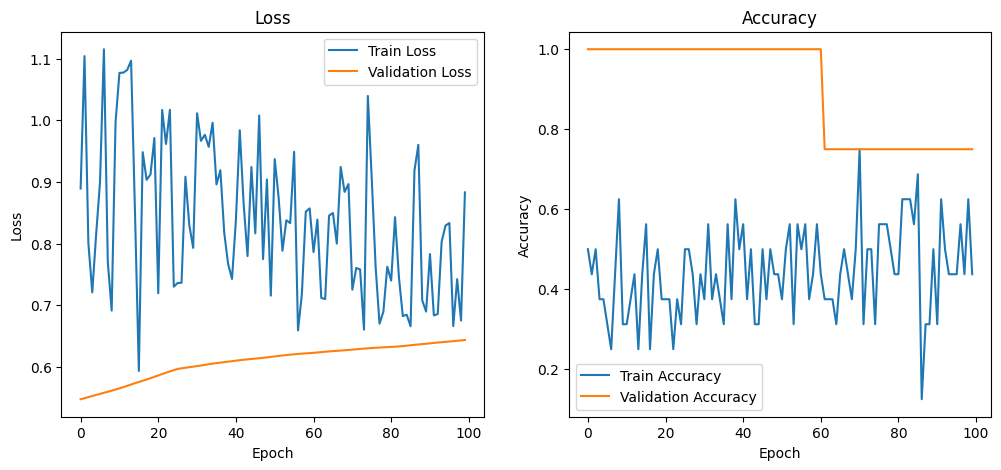

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Validation Loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy plot
ax[1].plot(history.history['accuracy'], label='Train Accuracy')
ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.show();

### **Visualize the Neural Network Architecture**

Using TensorFlow/Keras tools to visualize the network architecture:

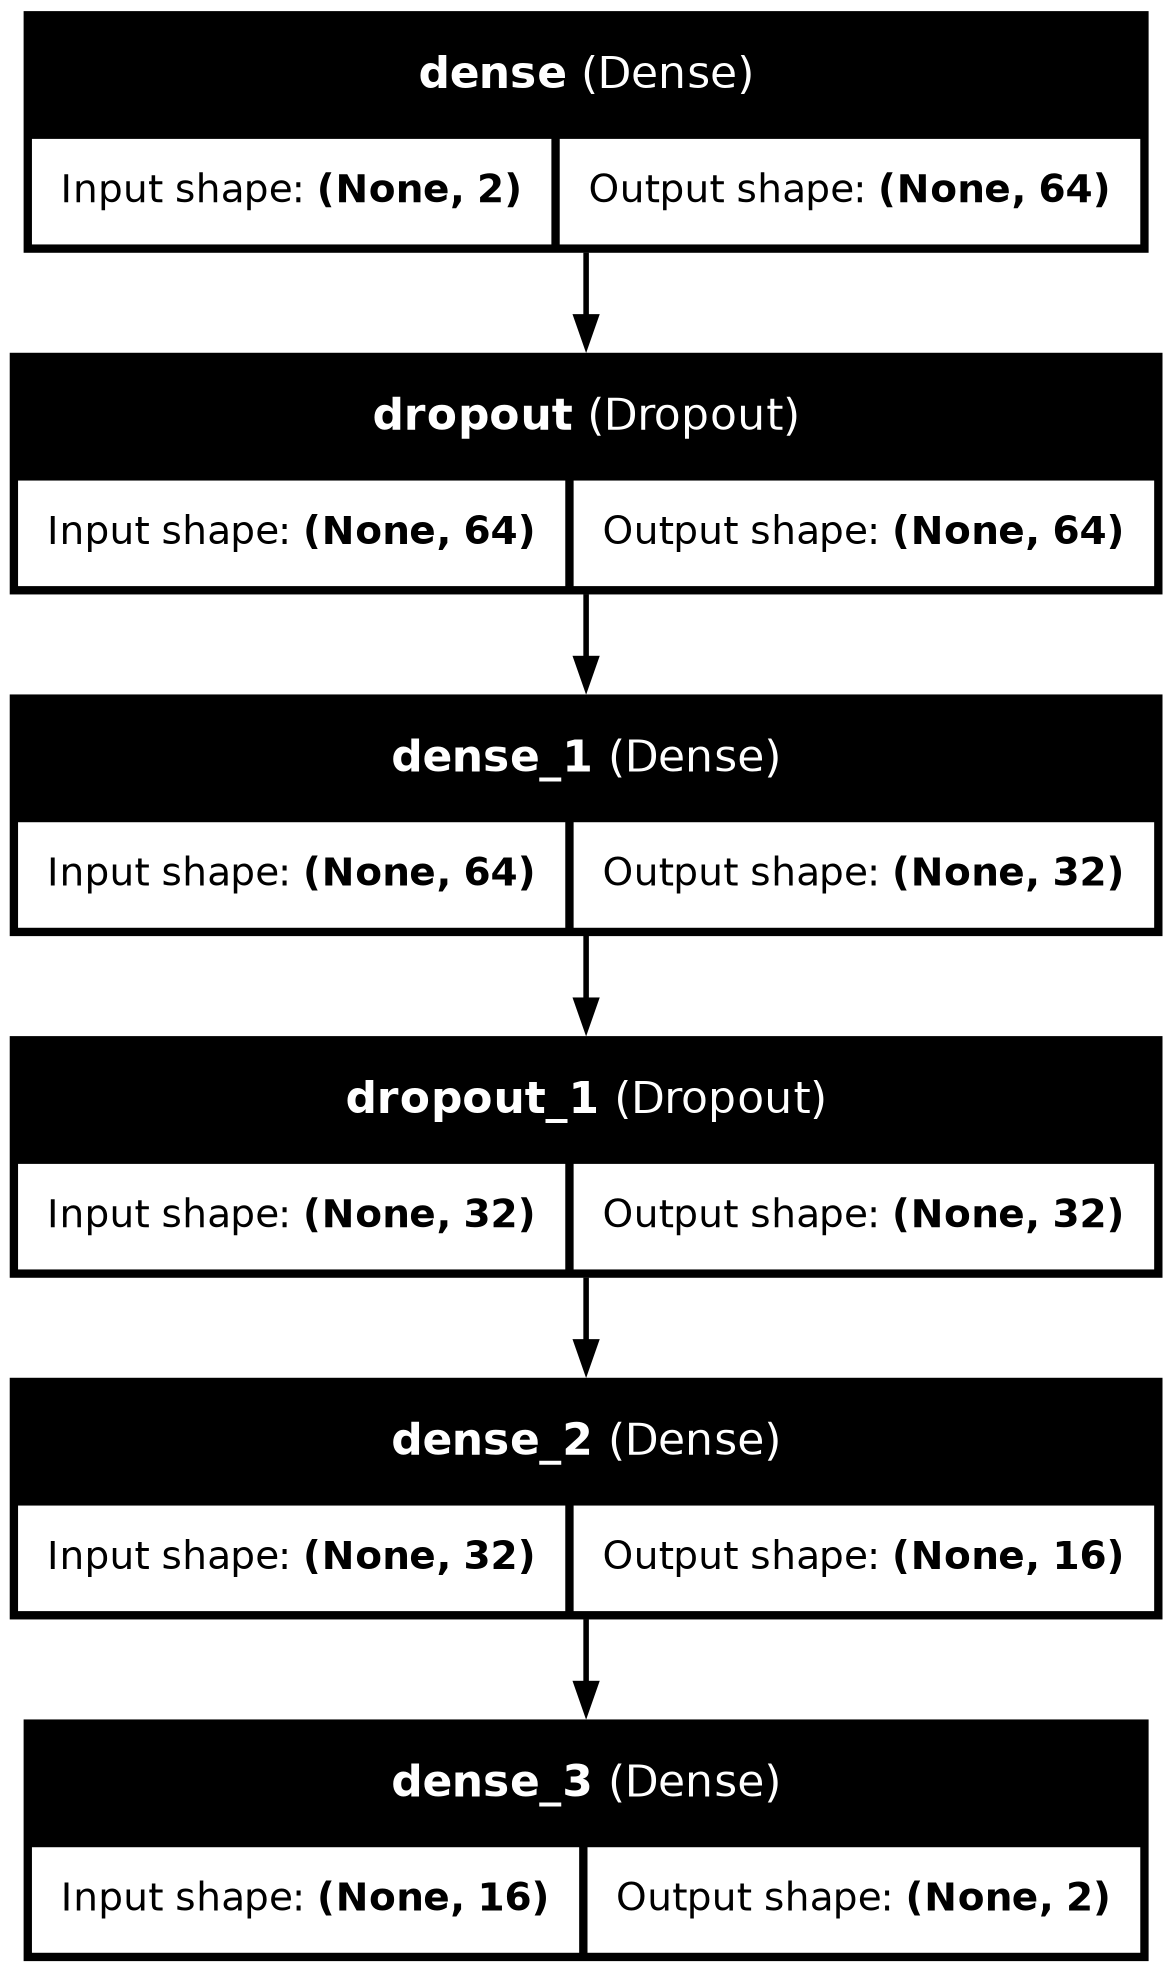

In [10]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# **The End :)**